In [1]:
import matplotlib.pyplot as plt
import pickle
from H2_631G import K, E_fcis

/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: Prefer the new nk.driver.VMC_SR over VMC which supports minSR and SPRING.

H2 分子基本信息
HF energy = -0.99749729 Ha
Total electrons = (1, 1)
Total basis functions = 4
H₂ FCI 基准能量
E0 = -1.05434745 Ha  |  激发能: 0.0000 eV
E1 = -0.95790573 Ha  |  激发能: 2.6243 eV
E2 = -0.66895227 Ha  |  激发能: 10.4871 eV
E3 = -0.55140192 Ha  |  激发能: 13.6859 eV
E4 = -0.02803278 Ha  |  激发能: 27.9275 eV
E5 = -0.01450343 Ha  |  激发能: 28.2956 eV
E6 = -0.00518297 Ha  |  激发能: 28.5492 eV
E7 = 0.02397075 Ha  |  激发能: 29.3425 eV
E8 = 0.23432390 Ha  |  激发能: 35.0666 eV
E9 = 0.25720575 Ha  |  激发能: 35.6892 eV
E10 = 0.49958128 Ha  |  激发能: 42.2846 eV
E11 = 0.50024484 Ha  |  激发能: 42.3026 eV

HF reference state: [0 0 0 1 0 0 0 1]
single_edges: [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3), (4, 5), (4, 6), (4, 7), (5, 6), (5, 7), (6, 7)]


In [8]:
with open('./data/26-09-17-18-42_history_natural_gradient_H2_molecule_K4.pkl', 'rb') as f:
    history = pickle.load(f)
history.keys()

dict_keys(['steps', 'logpsi_mean', 'logpsi_min', 'logpsi_max', 'grad_norm_raw', 'grad_norm_natural', 'grad_norm_per_param', 'E_L_real', 'E_L_imag', 'loss', 'first_step', 'save_interval', 'Energy_levels', 'params'])

Text(0, 0.5, 'grad_norm_per_param')

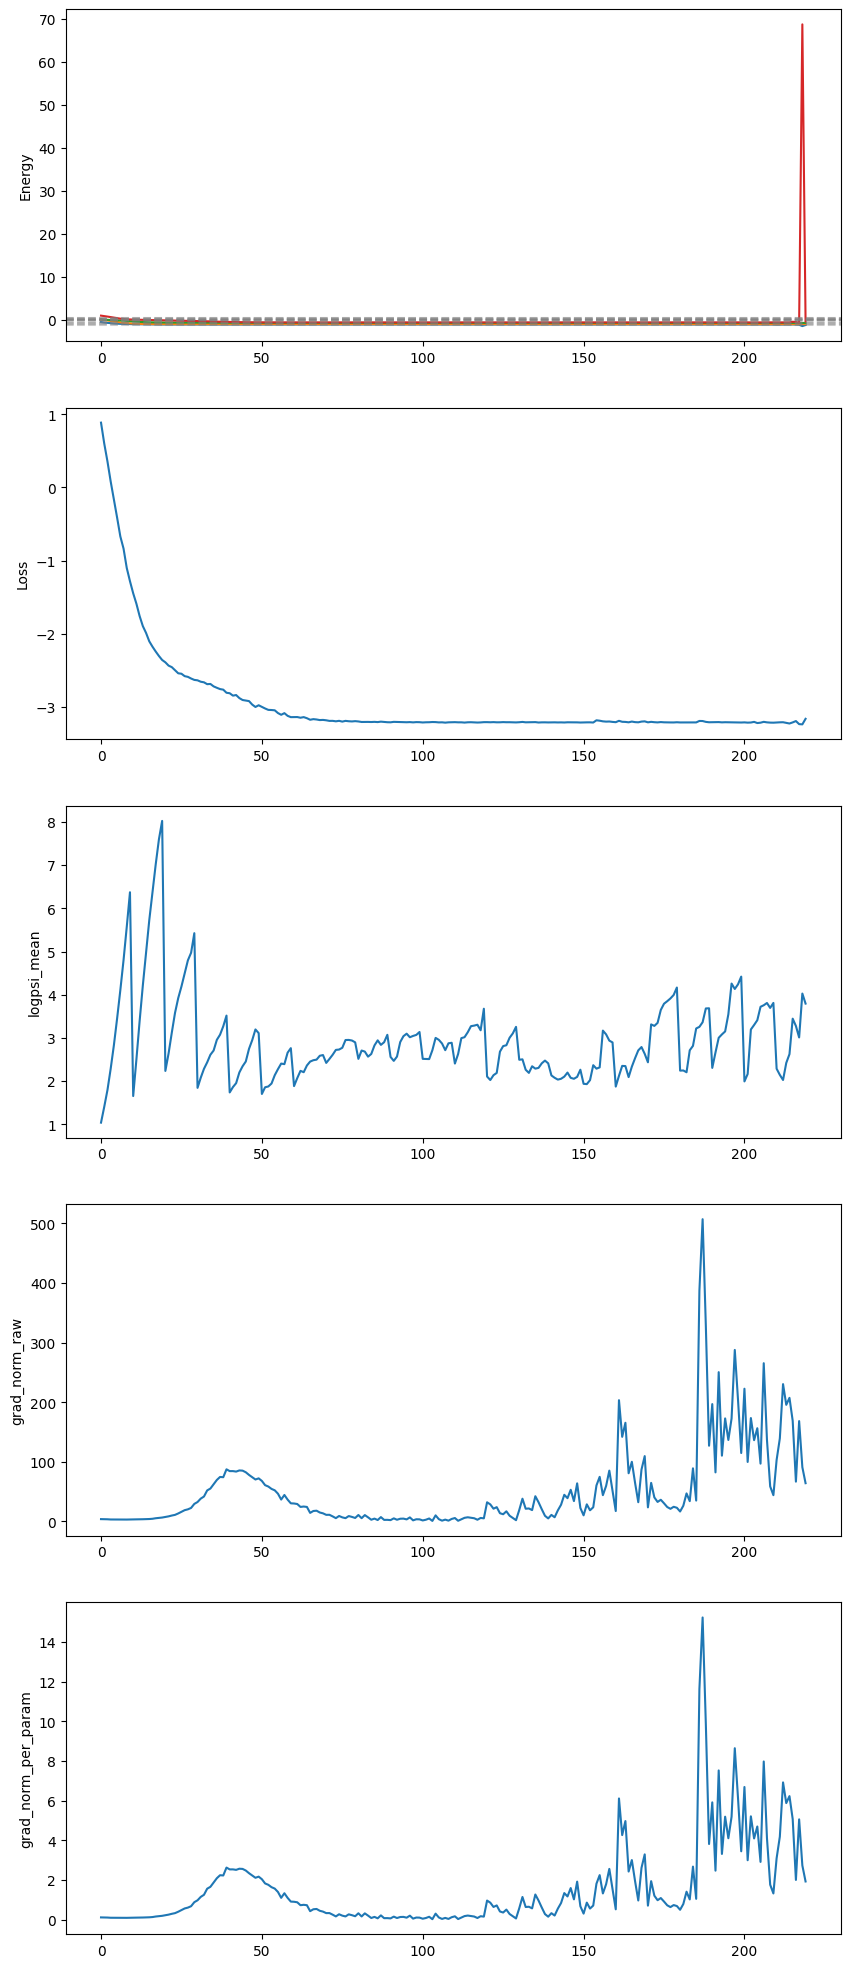

In [ ]:
fig,axs = plt.subplots(5, 1, figsize=(10, 25))
axs[0].plot(history['steps'],history["Energy_levels"])
for i in E_fcis:
    axs[0].axhline(i, color='gray', ls='--', alpha=0.4)

axs[0].set_ylabel("Energy")
axs[0].set_ylim()
axs[1].plot(history['steps'],history["loss"])
axs[1].set_ylabel("Loss")
axs[2].plot(history['steps'],history["logpsi_mean"])
axs[2].set_ylabel("logpsi_mean")
axs[3].plot(history['steps'],history["grad_norm_raw"])
axs[3].set_ylabel("grad_norm_raw")
axs[4].plot(history['steps'],history["grad_norm_per_param"])
axs[4].set_ylabel("grad_norm_per_param")


Text(0.5, 0, 'Steps')

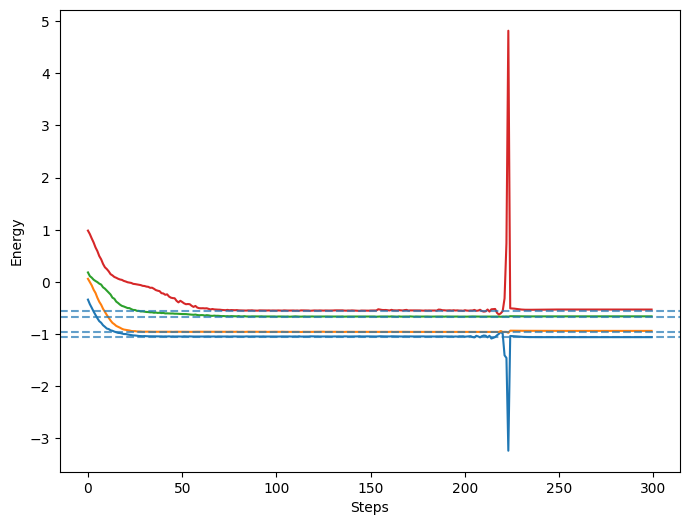

In [7]:

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(history['steps'],history["Energy_levels"])

for energy_index in range(K):
    ax.axhline(E_fcis[energy_index],linestyle="--", alpha=0.7, label=f"$E_{energy_index}$ (CAS Exact)")



ax.set_ylabel("Energy")
ax.set_xlabel("Steps")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig,axs = plt.subplots(5, 1, figsize=(10, 25))

# ===== 竖线位置：每隔10个采样点 =====
vline_x = history['steps'][::10]

axs[0].plot(history['steps'], history["Energy_levels"])
axs[0].set_ylabel("Energy")
for x in vline_x:
    axs[0].axvline(x, color='gray', ls='--', alpha=0.4)

axs[1].plot(history['steps'], history["loss"])
axs[1].set_ylabel("Loss")
for x in vline_x:
    axs[1].axvline(x, color='gray', ls='--', alpha=0.4)

axs[2].plot(history['steps'], history["logpsi_mean"])
axs[2].set_ylabel("logpsi_mean")
for x in vline_x:
    axs[2].axvline(x, color='gray', ls='--', alpha=0.4)

axs[3].plot(history['steps'], history["grad_norm_raw"])
axs[3].set_ylabel("grad_norm_raw")
for x in vline_x:
    axs[3].axvline(x, color='gray', ls='--', alpha=0.4)

axs[4].plot(history['steps'], history["grad_norm_per_param"])
axs[4].set_ylabel("grad_norm_per_param")
for x in vline_x:
    axs[4].axvline(x, color='gray', ls='--', alpha=0.4)

plt.tight_layout()
plt.show()
